
# Molecular Mechanics Basics

This lesson introduces the basic ideas of **molecular mechanics (MM)**. The central idea is simple:

- We do **not** solve the electronic Schrödinger equation.
- Instead, we write down an **empirical energy function** for the nuclei.
- The total energy is written as a sum of simple terms for bonded and nonbonded interactions.

A common molecular mechanics energy function is

\begin{equation}
E_{\text{MM}} =
E_{\text{bond}} +
E_{\text{angle}} +
E_{\text{dihedral}} +
E_{\text{nonbonded}}
\end{equation}

where

\begin{equation}
E_{\text{nonbonded}} = E_{\text{vdW}} + E_{\text{elec}}.
\end{equation}

By the end of this notebook, you should be able to:

1. Explain what molecular mechanics is.
2. Identify the major components of a force field.
3. Interpret the shapes of common MM energy functions.
4. Relate each energy term to a physical molecular distortion.

---



## 1. What is Molecular Mechanics?

In molecular mechanics, atoms are treated as particles connected by springs and interacting through simple classical potentials.

### Main idea
Instead of explicitly treating electrons, we approximate the potential energy surface using parameterized functions.

### Why do this?
- It is **much faster** than quantum mechanics.
- It allows simulations of **large molecules**, including proteins and nucleic acids.
- It provides forces, which makes **molecular dynamics** possible.

### What is lost?
- No explicit electronic structure
- No bond breaking/forming in standard MM
- Accuracy depends on the **force field parameters**

A typical force field is defined by:
- a mathematical form for each energy term
- parameters such as equilibrium bond lengths, force constants, charges, and van der Waals radii

---


In [1]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["legend.fontsize"] = 10


![image.png](img/bond_angle_dihedral.png)


## 2. Bond Stretching

The simplest approximation for a bond is a **harmonic potential**:

\begin{equation}
E_{\text{bond}}(r) = \frac{1}{2} k_r (r-r_0)^2
\end{equation}

where:
- $r$ = bond length
- $r_0$ = equilibrium bond length
- $k_r$ = bond force constant

### Interpretation
- The energy is lowest at $r=r_0$.
- Small deviations cost energy quadratically.
- This is a good approximation for **small displacements** near equilibrium.

### Limitation
A harmonic potential becomes unrealistic for very large stretch distances because it does **not** describe bond dissociation correctly.



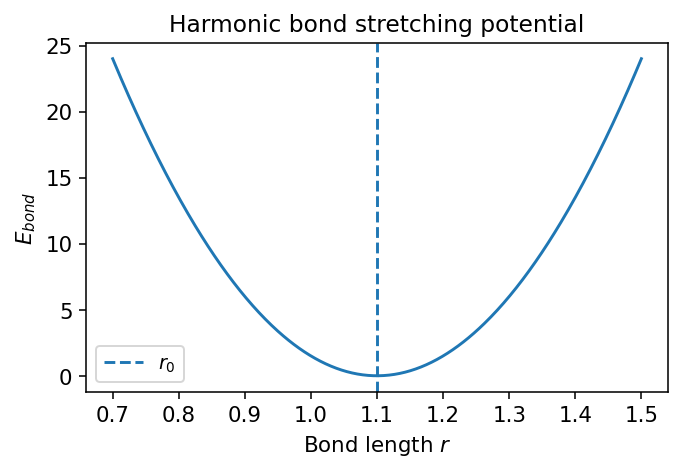

In [2]:

def bond_energy(r, k=300.0, r0=1.10):
    return 0.5 * k * (r - r0)**2

r = np.linspace(0.7, 1.5, 500)
E_bond = bond_energy(r)

plt.figure(figsize=(5, 3.5))
plt.plot(r, E_bond)
plt.axvline(1.10, linestyle="--", label=r"$r_0$")
plt.xlabel("Bond length $r$")
plt.ylabel(r"$E_{bond}$")
plt.title("Harmonic bond stretching potential")
plt.legend()
plt.tight_layout()
plt.show()



### Discussion
- The curvature near the minimum is controlled by $k_r$.
- A larger $k_r$ means a stiffer bond.



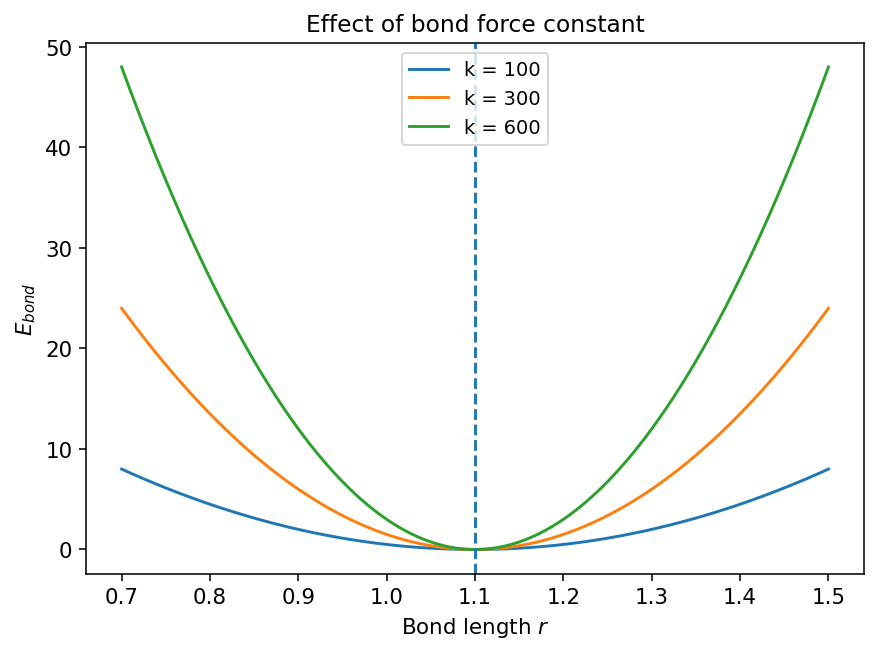

In [3]:

r = np.linspace(0.7, 1.5, 500)
for k in [100, 300, 600]:
    plt.plot(r, bond_energy(r, k=k, r0=1.10), label=f"k = {k}")

plt.axvline(1.10, linestyle="--")
plt.xlabel("Bond length $r$")
plt.ylabel(r"$E_{bond}$")
plt.title("Effect of bond force constant")
plt.legend()
plt.tight_layout()
plt.show()



## 3. Angle Bending

Bond angles are also often modeled harmonically:

\begin{equation}
E_{\text{angle}}(\theta) = \frac{1}{2} k_\theta (\theta-\theta_0)^2
\end{equation}

where:
- $\theta$ = bond angle
- $\theta_0$ = equilibrium angle
- $k_\theta$ = angle force constant

This has the same mathematical form as bond stretching, but now the coordinate is an angle.



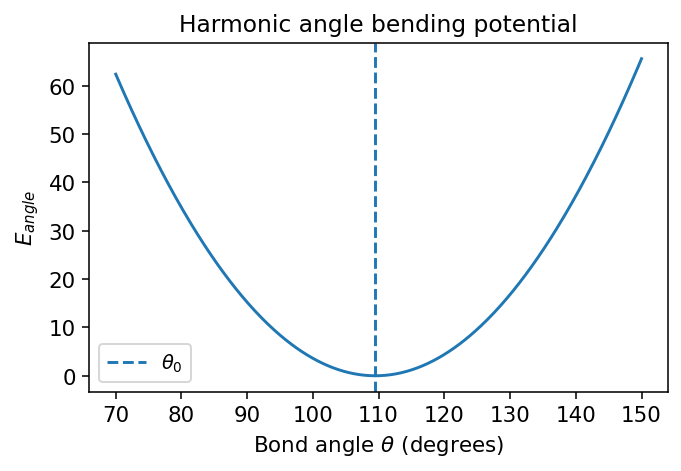

In [4]:

def angle_energy(theta_deg, k=0.08, theta0_deg=109.5):
    return 0.5 * k * (theta_deg - theta0_deg)**2

theta = np.linspace(70, 150, 500)
E_angle = angle_energy(theta)

plt.figure(figsize=(5, 3.5))
plt.plot(theta, E_angle)
plt.axvline(109.5, linestyle="--", label=r"$\theta_0$")
plt.xlabel(r"Bond angle $\theta$ (degrees)")
plt.ylabel(r"$E_{angle}$")
plt.title("Harmonic angle bending potential")
plt.legend()
plt.tight_layout()
plt.show()



### Physical picture
- Compressing or opening a bond angle raises the energy.
- As with bonds, the harmonic form works best for **small distortions**.

---



## 4. Dihedral (Torsional) Rotation

Dihedral angles are different. Rotation about a bond is often **periodic**, so force fields typically use a periodic cosine form such as

\begin{equation}
E_{\text{dihedral}}(\phi) =
\frac{V_n}{2}\left[1+\cos(n\phi-\delta)\right]
\end{equation}

where:
- $\phi$ = dihedral angle
- $V_n$ = barrier height parameter
- $n$ = periodicity
- $\delta$ = phase shift

### Interpretation
- The energy repeats every full rotation.
- Multiple minima may exist depending on the value of \(n\).
- Dihedral terms are crucial for conformational preferences.



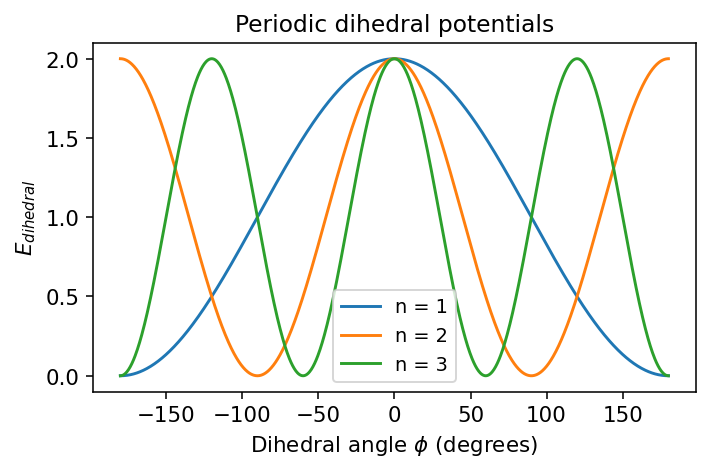

In [5]:

def dihedral_energy(phi_deg, Vn=2.0, n=3, delta_deg=0.0):
    phi = np.deg2rad(phi_deg)
    delta = np.deg2rad(delta_deg)
    return 0.5 * Vn * (1 + np.cos(n * phi - delta))

phi_deg = np.linspace(-180, 180, 1000)

plt.figure(figsize=(5.2, 3.5))
for n in [1, 2, 3]:
    plt.plot(phi_deg, dihedral_energy(phi_deg, Vn=2.0, n=n, delta_deg=0), label=f"n = {n}")

plt.xlabel(r"Dihedral angle $\phi$ (degrees)")
plt.ylabel(r"$E_{dihedral}$")
plt.title("Periodic dihedral potentials")
plt.legend()
plt.tight_layout()
plt.show()


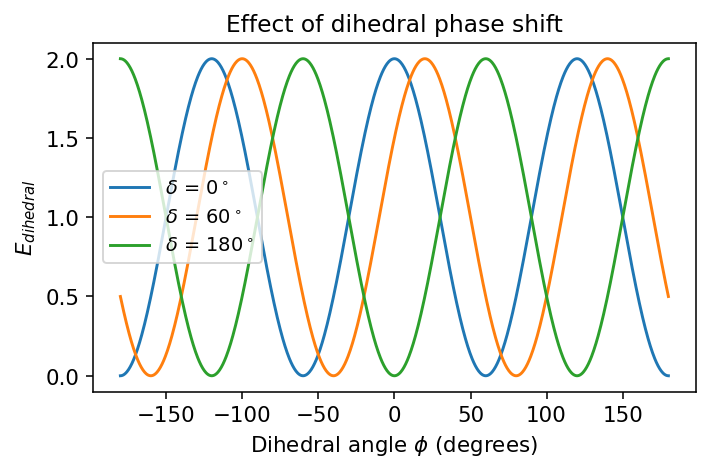

In [6]:

plt.figure(figsize=(5.2, 3.5))
for delta in [0, 60, 180]:
    plt.plot(phi_deg, dihedral_energy(phi_deg, Vn=2.0, n=3, delta_deg=delta), label=fr"$\delta$ = {delta}$^\circ$")

plt.xlabel(r"Dihedral angle $\phi$ (degrees)")
plt.ylabel(r"$E_{dihedral}$")
plt.title("Effect of dihedral phase shift")
plt.legend()
plt.tight_layout()
plt.show()



### Why torsions matter
Many important conformational changes in molecules and biomolecules occur through rotations around bonds. In proteins, backbone dihedral angles are especially important because they help determine secondary structure and overall conformation.

---



## 5. Nonbonded Interactions

\begin{equation}
E_{\text{nonbonded}} = E_{\text{vdW}} + E_{\text{elec}}.
\end{equation}

Two major nonbonded terms are usually included:

1. **van der Waals interactions**, often modeled with the Lennard-Jones potential
2. **Electrostatic interactions**, modeled with Coulomb's law

These interactions act between atoms that are not directly bonded (with some force-field-specific exclusions/scaling rules).




### 5a. Lennard-Jones Potential

A standard form is

\begin{equation}
E_{\text{LJ}}(r) = 4\varepsilon \left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6\right]
\end{equation}

where:
- $r$ = interatomic distance
- $\varepsilon$ = well depth
- $\sigma$ = distance where the potential crosses zero

### Interpretation
- At very short distance: strong repulsion
- At intermediate distance: attraction
- At long distance: approaches zero from below



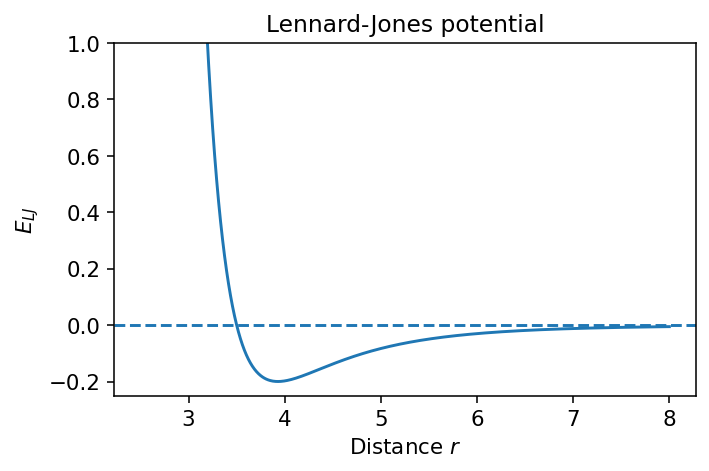

In [7]:

def lj_energy(r, epsilon=0.20, sigma=3.5):
    return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)

r = np.linspace(2.5, 8.0, 800)
E_lj = lj_energy(r)

plt.figure(figsize=(5.2, 3.5))
plt.plot(r, E_lj)
plt.axhline(0, linestyle="--")
plt.ylim(-0.25, 1.0)
plt.xlabel("Distance $r$")
plt.ylabel(r"$E_{LJ}$")
plt.title("Lennard-Jones potential")
plt.tight_layout()
plt.show()



### 5b. Coulomb Potential

Electrostatics are usually modeled by

\begin{equation}
E_{\text{elec}}(r) = k_e \frac{q_1 q_2}{r}
\end{equation}

where:
- $q_1, q_2$ = partial charges
- $r$ = separation
- $k_e$ = electrostatic constant (unit-dependent)

The sign depends on the product $q_1q_2$:
- opposite charges attract
- like charges repel



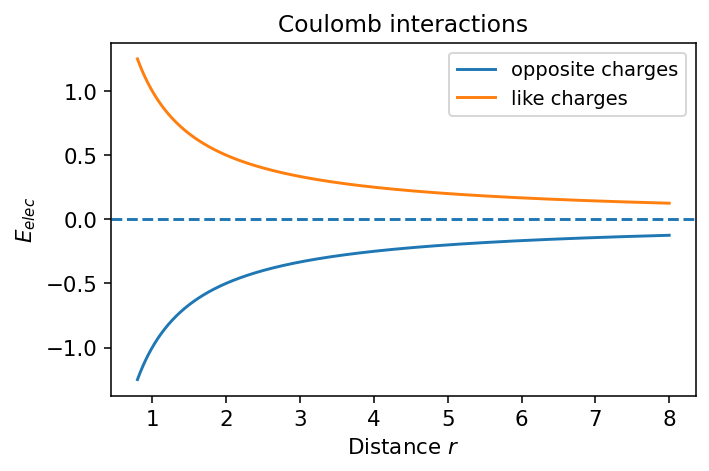

In [8]:

def coulomb_energy(r, q1=1.0, q2=-1.0, ke=1.0):
    return ke * q1 * q2 / r

r = np.linspace(0.8, 8.0, 800)

plt.figure(figsize=(5.2, 3.5))
plt.plot(r, coulomb_energy(r, q1=1, q2=-1), label="opposite charges")
plt.plot(r, coulomb_energy(r, q1=1, q2=1), label="like charges")
plt.axhline(0, linestyle="--")
plt.xlabel("Distance $r$")
plt.ylabel(r"$E_{elec}$")
plt.title("Coulomb interactions")
plt.legend()
plt.tight_layout()
plt.show()



## 6. Combined Nonbonded Picture

For two neutral atoms, the Lennard-Jones term often gives the qualitative shape:
- repulsive wall at short distance
- weak attraction at moderate distance

For charged species, adding Coulomb interactions can change the picture dramatically.



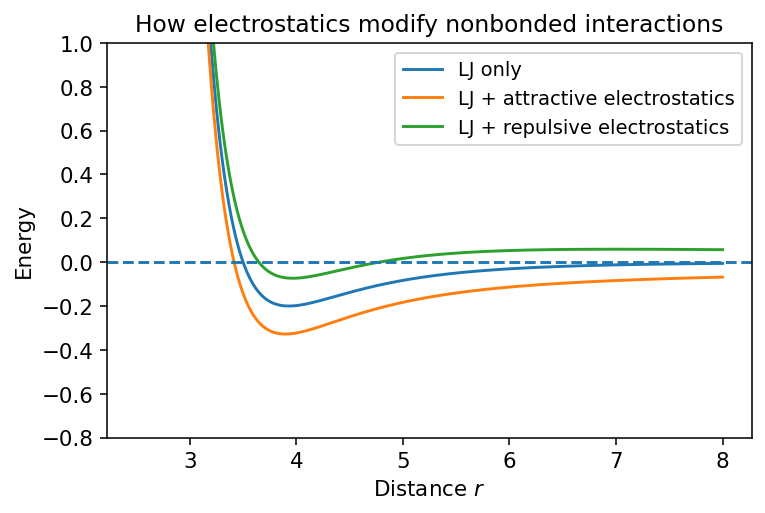

In [9]:

r = np.linspace(2.5, 8.0, 800)
lj = lj_energy(r, epsilon=0.20, sigma=3.5)
elec_attr = coulomb_energy(r, q1=0.5, q2=-0.5, ke=2.0)
elec_rep = coulomb_energy(r, q1=0.5, q2=0.5, ke=2.0)

plt.figure(figsize=(5.6, 3.8))
plt.plot(r, lj, label="LJ only")
plt.plot(r, lj + elec_attr, label="LJ + attractive electrostatics")
plt.plot(r, lj + elec_rep, label="LJ + repulsive electrostatics")
plt.axhline(0, linestyle="--")
plt.ylim(-0.8, 1.0)
plt.xlabel("Distance $r$")
plt.ylabel("Energy")
plt.title("How electrostatics modify nonbonded interactions")
plt.legend()
plt.tight_layout()
plt.show()



## 7. Total Force Field Energy

A common textbook expression is

\begin{equation}
E_{\text{MM}} =
\sum_{\text{bonds}} \frac{1}{2}k_r(r-r_0)^2
+
\sum_{\text{angles}} \frac{1}{2}k_\theta(\theta-\theta_0)^2
+
\sum_{\text{dihedrals}} \frac{V_n}{2}[1+\cos(n\phi-\delta)]
+
\sum_{i<j}
\left[
4\varepsilon_{ij}\left(
\left(\frac{\sigma_{ij}}{r_{ij}}\right)^{12}
-
\left(\frac{\sigma_{ij}}{r_{ij}}\right)^6
\right)
+
k_e\frac{q_i q_j}{r_{ij}}
\right]
\end{equation}

This is the potential energy function used to compute:
- molecular geometries (via minimization)
- forces
- molecular dynamics trajectories

---



## 8. What Force Fields Try to Capture

A force field tries to reproduce:
- equilibrium geometries
- vibrational stiffness
- conformational preferences
- intermolecular packing
- thermodynamic properties

Examples of common biomolecular force fields include:
- **AMBER**
- **CHARMM**
- **OPLS**
- **GROMOS**

Different force fields use slightly different functional forms and parameterization strategies.




## 9. Important Limitations of Molecular Mechanics

Molecular mechanics is powerful, but it has limitations.

### Standard MM usually cannot:
- break or form covalent bonds
- describe changes in electronic state
- capture polarization explicitly (in many fixed-charge force fields)

### Also important:
- parameters may not transfer perfectly to every chemical environment
- good sampling is still required in MD
- a simple functional form may miss subtle physics

Even so, MM is enormously useful because it makes simulations of large systems computationally feasible.

---



## 10. Short Concept Check

Try answering these before moving on.

1. Why is a harmonic bond potential only an approximation?
2. Which energy term is periodic in the coordinate?
3. What happens to the Lennard-Jones potential at very short distance?
4. Why is molecular mechanics much faster than quantum mechanics?
5. Which MM term is most directly associated with conformational rotation around a bond?




## 11. Simple Worked Example

Suppose a molecule has:
- one stretched bond
- one bent angle
- one torsion
- one nonbonded atom pair

Then the total energy is just the sum of those contributions.

Below is a toy example showing how the contributions add up.



In [10]:

# Toy values
r = 1.18
theta = 116.0
phi = 60.0
r_nb = 3.8

E_b = bond_energy(r, k=300.0, r0=1.10)
E_a = angle_energy(theta, k=0.08, theta0_deg=109.5)
E_d = dihedral_energy(phi, Vn=2.0, n=3, delta_deg=0.0)
E_nb = lj_energy(r_nb, epsilon=0.20, sigma=3.5) + coulomb_energy(r_nb, q1=0.4, q2=-0.3, ke=2.0)

E_total = E_b + E_a + E_d + E_nb

print(f"Bond energy       = {E_b:8.4f}")
print(f"Angle energy      = {E_a:8.4f}")
print(f"Dihedral energy   = {E_d:8.4f}")
print(f"Nonbonded energy  = {E_nb:8.4f}")
print("-" * 30)
print(f"Total MM energy   = {E_total:8.4f}")


Bond energy       =   0.9600
Angle energy      =   1.6900
Dihedral energy   =   0.0000
Nonbonded energy  =  -0.2534
------------------------------
Total MM energy   =   2.3966



## 13. Suggested Exercises

1. Modify the bond force constant and describe how the curve changes.
2. Change the periodicity \(n\) in the torsion term and count the number of minima over \(360^\circ\).
3. Change the sign of the charges in the Coulomb interaction and interpret the result.
4. For the Lennard-Jones potential, vary \(\varepsilon\) and \(\sigma\). What changes physically?
5. Write one sentence explaining the difference between a bonded interaction and a nonbonded interaction.

